In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt


CANTIDAD DE LOGS

In [2]:
df = pd.read_csv("server_logs.csv")
print(f"Hay un total de {len(df)} logs")

Hay un total de 5795 logs


FRECUENCIA DE NIVELES DIVIDIDOS POR SEVERIDAD

In [3]:
print("FRECUENCIA DE SEVERIDADES")
print(df["severity"].value_counts().head())

FRECUENCIA DE SEVERIDADES
severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64


SERVICIO CON MAS LOGS GENERADOS Y CON MENOS LOGS GENERADOS

In [4]:
print("SERVICIO POR LOGS")
servicio = df["service_name"].value_counts()
print(f"El servicio con mas logs es: {servicio.idxmax()} : {servicio.max()}")
print(f"El servicio con menos logs es: {servicio.idxmin()} : {servicio.min()}")

SERVICIO POR LOGS
El servicio con mas logs es: api-gateway : 1509
El servicio con menos logs es: notification-service : 645


MENSAJE QUE MAS SE REPITIO

In [5]:
print("TOP 5 DE MENSAJES MAS REPETIDOS")
print(df["message"]. value_counts().head(5))

TOP 5 DE MENSAJES MAS REPETIDOS
message
Health check OK                                   1196
Background job completed                          1185
Request completed                                 1161
Order creation failed - inventory lock timeout     197
Rate limit nearing threshold                       193
Name: count, dtype: int64


EL MENSAJE MAS MALO

In [6]:
severidad = df["severity"].isin(["ERROR","CRITICAL"])
status = df["status_code"] >= 500
bad_event = severidad | status

bad_column = df[bad_event]
bad_mensaje = bad_column["message"].value_counts()
print(f"El bad event mas repetido es: \n{bad_mensaje.head(1)}")

El bad event mas repetido es: 
message
Order creation failed - inventory lock timeout    197
Name: count, dtype: int64


DETECCION DEL MOMENTO CRITICO

In [20]:
# --- 6.2 DETECCIÓN DEL MOMENTO CRÍTICO ---

# 1. Aseguramos que el timestamp sea datetime y creamos la columna de ventanas (bins)
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])
df['timestamp_event_5min'] = df['timestamp_event'].dt.floor('5min')

# 2. Definición de Bad Event (Punto 5)
is_bad_global = (df['severity'].isin(['ERROR', 'CRITICAL'])) | (df['status_code'] >= 500)
df['is_bad'] = is_bad_global
df['is_5xx'] = df['status_code'] >= 500

df_windows = df.groupby('timestamp_event_5min').agg(
    total_events=('is_bad', 'count'),
    bad_events=('is_bad', 'sum'),
    events_5xx=('is_5xx', 'sum') # Agregamos esto
).reset_index()
# 4. Calculamos el bad_rate
df_windows['bad_rate'] = df_windows['bad_events'] / df_windows['total_events']
df_windows['pct_5xx'] = df_windows['events_5xx'] / df_windows['total_events'] # Agregamos esto

# 5. Aplicamos la REGLA: total_events >= 20 (Aquí se define la variable que te faltaba)
df_windows_filtrado = df_windows[df_windows['total_events'] >= 20].copy()

# Mostramos el Top 5 para cumplir con el requisito 6.2
print("--- 6.2 Top 5 Ventanas con mayor Bad Rate (mínimo 20 eventos) ---")
top_5_ventanas = df_windows_filtrado.sort_values('bad_rate', ascending=False).head(5)
print(top_5_ventanas)
print("\n")

--- 6.2 Top 5 Ventanas con mayor Bad Rate (mínimo 20 eventos) ---
         timestamp_event_5min  total_events  bad_events  events_5xx  bad_rate  \
134 2026-01-10 11:10:00+00:00           189         110         110  0.582011   
135 2026-01-10 11:15:00+00:00           228         129         129  0.565789   
136 2026-01-10 11:20:00+00:00           111          59          59  0.531532   
462 2026-01-11 14:35:00+00:00           255         117         117  0.458824   
461 2026-01-11 14:30:00+00:00           156          68          68  0.435897   

      pct_5xx  
134  0.582011  
135  0.565789  
136  0.531532  
462  0.458824  
461  0.435897  




DIAGNOSTICO DE LOS MOMENTOS CRITICOS

In [ ]:
# --- 6.3 DIAGNÓSTICO DENTRO DEL MOMENTO CRÍTICO ---

# 1. Seleccionamos el Momento Crítico (Top 1)
momento_critico_row = top_5_ventanas.iloc[0]
inicio_ventana_critica = momento_critico_row['timestamp_event_5min']

# 2. Filtramos el DataFrame original para obtener los logs de esa ventana exacta
df_critico = df[df['timestamp_event_5min'] == inicio_ventana_critica].copy()

# 3. Filtramos solo los Bad Events de esa ventana para los rankings
df_bad_critico = df_critico[df_critico['is_bad'] == True].copy()

print(f"--- 6.3 DIAGNÓSTICO VENTANA CRÍTICA: {inicio_ventana_critica} ---")
print(f"Criterio: Por cantidad de bad events (N={len(df_bad_critico)})\n")

# A. Ranking de servicios
print("1. Bad events por service_name:")
print(f"{df_bad_critico['service_name'].value_counts()}")
print("-" * 30)

# B. Top 5 mensajes
print("2. Top 5 message en bad events:")
print(f"{df_bad_critico['message'].value_counts().head(5)}")
print("-" * 30)

# C. Top 5 endpoints
print("3. Top 5 endpoint más comprometidos:")
print(f"{df_bad_critico['endpoint'].value_counts().head(5)}")

--- 6.3 DIAGNÓSTICO VENTANA CRÍTICA: 2026-01-10 11:10:00+00:00 ---
Criterio: Por cantidad de bad events (N=110)

1. Bad events por service_name:
service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

------------------------------
2. Top 5 message en bad events:
message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

------------------------------
3. Top 5 endpoint más comprometidos:
endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64



BASELINE VS MOMENTO CRITICO

In [16]:
# --- 6.4 “QUÉ CAMBIÓ” (INCIDENTE VS BASELINE) ---

# 1. Definimos el filtro del momento crítico basado en el timestamp de la ventana
# Usamos el 'inicio_ventana_critica' que identificamos en el paso 6.3
inicio_incidente = inicio_ventana_critica
fin_incidente = inicio_ventana_critica + pd.Timedelta(minutes=5)

# 2. Separamos el dataset: Incidente vs Baseline
mask_incidente = (df['timestamp_event'] >= inicio_incidente) & (df['timestamp_event'] < fin_incidente)

df_incidente = df.loc[mask_incidente].copy()
df_baseline = df.loc[~mask_incidente].copy()

# 3. Cálculos de métricas (Usando la columna 'is_bad' que ya definimos globalmente)
def calcular_metricas(dataframe):
    total = len(dataframe)
    if total == 0: return [0, 0, 0, 0]
    
    bad_rate = dataframe['is_bad'].mean() # El promedio de un booleano es su tasa (0 a 1)
    avg_latency = dataframe['latency_ms'].mean()
    pct_5xx = (dataframe['status_code'] >= 500).mean()
    
    return [total, bad_rate, avg_latency, pct_5xx]

metricas_inc = calcular_metricas(df_incidente)
metricas_base = calcular_metricas(df_baseline)

# 4. Construir tabla comparativa final
tabla_comparacion = pd.DataFrame({
    'métrica': ['total_events', 'bad_rate', 'avg_latency_ms', 'pct_5xx'],
    'incidente': metricas_inc,
    'baseline': metricas_base
})

# Formateamos para que sea legible (Redondeo a 4 decimales)
tabla_comparacion = tabla_comparacion.set_index('métrica').round(4)

print("--- 6.4 COMPARACIÓN: MOMENTO CRÍTICO VS BASELINE ---")
print(tabla_comparacion)

--- 6.4 COMPARACIÓN: MOMENTO CRÍTICO VS BASELINE ---
                incidente   baseline
métrica                             
total_events     189.0000  5606.0000
bad_rate           0.5820     0.1400
avg_latency_ms  1589.6878   521.0944
pct_5xx            0.5820     0.1400


GRAFICO 1 

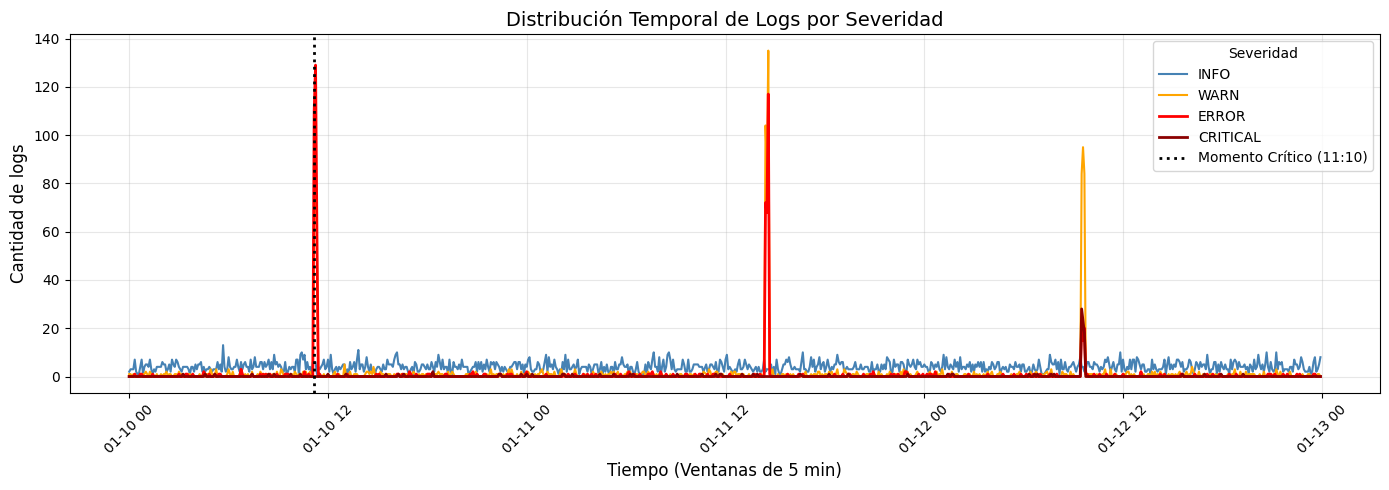

In [22]:
# --- Gráfico 1: Conteo de eventos por severidad en bins de 5 min ---

# 1. Agrupamos los datos usando la columna de ventanas que ya tenemos definida
df_sev = (
    df.groupby(['timestamp_event_5min', 'severity'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 2. Configuración del gráfico
plt.figure(figsize=(14, 5))

colores = {
    'INFO': 'steelblue',
    'WARN': 'orange',
    'ERROR': 'red',
    'CRITICAL': 'darkred'
}

# 3. Dibujamos las líneas asegurando el orden de importancia
for sev in ['INFO', 'WARN', 'ERROR', 'CRITICAL']:
    if sev in df_sev.columns:
        plt.plot(
            df_sev['timestamp_event_5min'], 
            df_sev[sev], 
            label=sev, 
            color=colores.get(sev, 'gray'),
            linewidth=2 if sev in ['ERROR', 'CRITICAL'] else 1.5
        )

# 4. Marcamos el momento crítico (Usando la variable global inicio_ventana_critica)
plt.axvline(
    x=inicio_ventana_critica, 
    color='black', 
    linestyle=':', 
    linewidth=2, 
    label=f'Momento Crítico ({inicio_ventana_critica.strftime("%H:%M")})'
)

# 5. Estética y etiquetas
plt.title('Distribución Temporal de Logs por Severidad', fontsize=14)
plt.xlabel('Tiempo (Ventanas de 5 min)', fontsize=12)
plt.ylabel('Cantidad de logs', fontsize=12)
plt.legend(title='Severidad', loc='upper right')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

GRAFICO 2

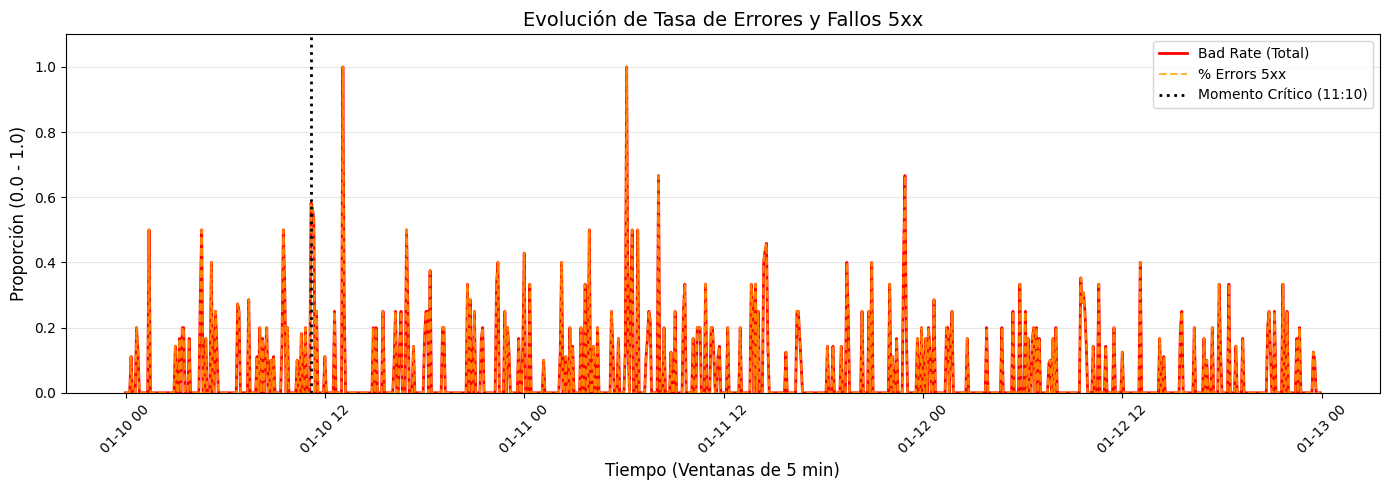

In [21]:
# --- Gráfico 2: bad_rate y %_5xx en bins de 5 min ---

plt.figure(figsize=(14, 5))

# Graficamos directamente desde df_windows (que tiene todas las ventanas temporales)
plt.plot(
    df_windows['timestamp_event_5min'], 
    df_windows['bad_rate'], 
    label='Bad Rate (Total)', 
    color='red', 
    linewidth=2
)

plt.plot(
    df_windows['timestamp_event_5min'], 
    df_windows['pct_5xx'], 
    label='% Errors 5xx', 
    color='orange', 
    linestyle='--', 
    alpha=0.8
)

# Línea vertical en el momento crítico (inicio_ventana_critica definido en 6.3)
plt.axvline(
    x=inicio_ventana_critica, 
    color='black', 
    linestyle=':', 
    linewidth=2, 
    label=f'Momento Crítico ({inicio_ventana_critica.strftime("%H:%M")})'
)

# Configuración de ejes y títulos
plt.title('Evolución de Tasa de Errores y Fallos 5xx', fontsize=14)
plt.xlabel('Tiempo (Ventanas de 5 min)', fontsize=12)
plt.ylabel('Proporción (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.1) # Un poco más de 1 para que la leyenda no tape el tope
plt.legend(loc='upper right')
plt.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

CONCLUSION 
El análisis de logs permite identificar que el momento crítico ocurrió exactamente a las 11:10, alcanzando un bad_rate máximo de 0.582, lo que representa un incremento severo frente al baseline de 0.141. El servicio con mayor impacto negativo fue orders-service, siendo el endpoint /orders/cancel el punto más comprometido del sistema. El mensaje de error dominante, "Order creation failed - inventory lock timeout", junto con el aumento observado en la latencia promedio durante el incidente, sugiere un cuello de botella o bloqueo en el manejo de transacciones de inventario. La correlación visual entre el aumento de severidades CRITICAL y la tasa de errores 5xx confirma una degradación real de la infraestructura en la ventana temporal identificada.